In [8]:
# Cell 1: Install required libraries
!pip install ortools -q
import time
import json
import os
from dataclasses import dataclass, asdict
from typing import List, Dict, Any
from ortools.sat.python import cp_model

print("Environment setup complete. OR-Tools loaded successfully!")


Environment setup complete. OR-Tools loaded successfully!


Advanced Metrics & Evaluation - classical_results.py

In [9]:
# Cell 2: Evaluation Metrics Definition (Including Degradation Costs & Violations)
@dataclass
class EvaluationMetrics:
    C_total: float          # Net cost (Charging cost - V2G revenue + Battery degradation cost)
    P_max: float            # Peak grid power demand
    E_V2G: float            # Total energy fed back to the grid
    N_unserved: int         # Number of unserved trips/demands
    N_violations: int       # Number of transformer/capacity violations
    runtime: float          # Execution time in seconds

    def to_dict(self) -> Dict[str, Any]:
        return asdict(self)

    def save_to_json(self, filepath: str):
        with open(filepath, 'w') as f:
            json.dump(self.to_dict(), f, indent=4)

def evaluate_schedule(
    schedule_data: dict,
    problem_data: dict,
    runtime: float
) -> EvaluationMetrics:
    electricity_prices = problem_data["prices"]
    v2g_tariffs = problem_data["v2g_prices"]
    grid_capacity = problem_data["grid_limit"]
    degrad_cost_per_kwh = problem_data.get("battery_degradation_cost", 0.05)

    time_steps = len(electricity_prices)
    power_profile = [0.0] * time_steps

    C_total = 0.0
    E_V2G = 0.0
    N_violations = 0

    N_unserved = len(schedule_data.get("unserved_trips", []))

    ev_profiles = schedule_data.get("ev_power_profiles", {})
    for ev_id, profile in ev_profiles.items():
        for t, p in enumerate(profile):
            if t < time_steps:
                power_profile[t] += p
                if p > 0:  # Charging
                    C_total += p * electricity_prices[t]
                elif p < 0:  # V2G discharge
                    energy_discharged = abs(p)
                    E_V2G += energy_discharged
                    C_total -= energy_discharged * (v2g_tariffs[t] - degrad_cost_per_kwh)

    P_max = max(power_profile) if power_profile else 0.0

    for t, p in enumerate(power_profile):
        if p > grid_capacity:
            N_violations += 1

    return EvaluationMetrics(
        C_total=round(C_total, 2),
        P_max=round(P_max, 2),
        E_V2G=round(E_V2G, 2),
        N_unserved=N_unserved,
        N_violations=N_violations,
        runtime=round(runtime, 4)
    )

Secondary Greedy Heuristic Baseline - greedy.py

In [10]:
# Cell 3: Enhanced Greedy Heuristic Model
def solve_greedy_heuristic(problem_data: dict) -> tuple:
    start_time = time.time()

    evs = problem_data["evs"]
    trips = problem_data["trips"]
    prices = problem_data["prices"]
    grid_limit = problem_data["grid_limit"]
    T = len(prices)

    sorted_trips = sorted(trips, key=lambda x: x["start_time"])
    grid_load = [0.0] * T
    ev_profiles = {ev["id"]: [0.0] * T for ev in evs}
    ev_battery = {ev["id"]: ev["initial_soc"] * ev["capacity"] for ev in evs}

    unserved_trips = []

    for trip in sorted_trips:
        assigned_ev = None
        for ev in evs:
            if ev_battery.get(ev["id"], 0) >= trip["energy_required"]:
                assigned_ev = ev["id"]
                break

        if not assigned_ev:
            unserved_trips.append(trip["id"])
            continue

        ev_battery[assigned_ev] -= trip["energy_required"]

        charge_window = range(trip["end_time"], min(T, trip["end_time"] + 4))
        cheapest_slot = min(charge_window, key=lambda t: prices[t]) if charge_window else None

        if cheapest_slot is not None:
            required_power = trip["energy_required"]
            available_headroom = grid_limit - grid_load[cheapest_slot]
            allocated_power = min(required_power, max(0.0, available_headroom))

            ev_profiles[assigned_ev][cheapest_slot] += allocated_power
            grid_load[cheapest_slot] += allocated_power
            ev_battery[assigned_ev] += allocated_power

    runtime = time.time() - start_time
    schedule_data = {
        "ev_power_profiles": ev_profiles,
        "unserved_trips": unserved_trips
    }
    return schedule_data, runtime

Advanced Google OR-Tools Model (ortools_model.py)

In [11]:
# Cell 4: Production-Grade OR-Tools CP-SAT Model with Mandatory Trip Routing & Safety Reserves
def solve_ortools_model(problem_data: dict, warm_start_hint: dict = None) -> tuple:
    start_time = time.time()

    evs = problem_data["evs"]
    trips = problem_data["trips"]
    prices = problem_data["prices"]
    v2g_prices = problem_data["v2g_prices"]
    grid_limit = problem_data["grid_limit"]
    degrad_cost = problem_data.get("battery_degradation_cost", 0.05)
    T = len(prices)

    model = cp_model.CpModel()
    SCALE = 100
    scaled_grid_limit = int(grid_limit * SCALE)

    charge = {}
    discharge = {}
    soc = {}
    assignment = {}

    # --- Decision Variables ---
    for ev in evs:
        ev_id = ev["id"]
        max_cap = int(ev["capacity"] * SCALE)
        for t in range(T + 1):
            soc[(ev_id, t)] = model.NewIntVar(0, max_cap, f"soc_{ev_id}_{t}")

        for t in range(T):
            charge[(ev_id, t)] = model.NewIntVar(0, int(ev.get("max_charge_rate", 15.0) * SCALE), f"charge_{ev_id}_{t}")
            discharge[(ev_id, t)] = model.NewIntVar(0, int(ev.get("max_discharge_rate", 15.0) * SCALE), f"discharge_{ev_id}_{t}")

    for trip in trips:
        trip_id = trip["id"]
        for ev in evs:
            ev_id = ev["id"]
            assignment[(trip_id, ev_id)] = model.NewBoolVar(f"assign_{trip_id}_{ev_id}")

    # --- Constraints ---
    # 1. MANDATORY TRIP ROUTING: Every single trip must be assigned to exactly one EV (Eliminates unserved trips)
    for trip in trips:
        trip_id = trip["id"]
        model.Add(sum(assignment[(trip_id, ev["id"])] for ev in evs) == 1)

    # 2. Initial State of Charge
    for ev in evs:
        ev_id = ev["id"]
        initial_energy = int(ev["initial_soc"] * ev["capacity"] * SCALE)
        model.Add(soc[(ev_id, 0)] == initial_energy)

    # 3. Battery Dynamics, Energy Balance & Safety Reserves
    for ev in evs:
        ev_id = ev["id"]
        max_cap = int(ev["capacity"] * SCALE)
        min_reserve = int(ev["capacity"] * 0.15 * SCALE) # 15% minimum safety reserve for trips

        for t in range(T):
            # Energy consumed by assigned trips starting at time t
            trip_drain = sum(
                assignment[(trip["id"], ev_id)] * int(trip["energy_required"] * SCALE)
                for trip in trips if trip["start_time"] == t
            )

            # SOC transition equation
            model.Add(
                soc[(ev_id, t + 1)] == soc[(ev_id, t)] + charge[(ev_id, t)] - discharge[(ev_id, t)] - trip_drain
            )
            # Hard upper and lower bounds
            model.Add(soc[(ev_id, t + 1)] <= max_cap)
            model.Add(soc[(ev_id, t + 1)] >= min_reserve)

    # 4. Transformer Capacity Constraints (Per Time Step)
    for t in range(T):
        total_power_t = []
        for ev in evs:
            ev_id = ev["id"]
            total_power_t.append(charge[(ev_id, t)])
            total_power_t.append(-discharge[(ev_id, t)])
        model.Add(sum(total_power_t) <= scaled_grid_limit)

    # --- Objective Function: Minimize Net Cost + Battery Degradation Penalty ---
    cost_terms = []
    for t in range(T):
        c_price = int(prices[t] * SCALE)
        v_price_net = int((v2g_prices[t] - degrad_cost) * SCALE)
        for ev in evs:
            ev_id = ev["id"]
            cost_terms.append(charge[(ev_id, t)] * c_price)
            cost_terms.append(-discharge[(ev_id, t)] * v_price_net)

    model.Minimize(sum(cost_terms))

    # --- Warm-Start Integration (Hints from Greedy Heuristic) ---
    if warm_start_hint:
        hint_profiles = warm_start_hint.get("ev_power_profiles", {})
        for ev_id, profile in hint_profiles.items():
            for t, p in enumerate(profile):
                if p > 0:
                    model.AddHint(charge[(ev_id, t)], int(p * SCALE))

    # --- Solve Model ---
    solver = cp_model.CpSolver()
    solver.parameters.max_time_in_seconds = 45.0
    status = solver.Solve(model)

    runtime = time.time() - start_time

    # --- Extract Results ---
    ev_power_profiles = {}
    for ev in evs:
        ev_id = ev["id"]
        profile = []
        for t in range(T):
            net_power = (solver.Value(charge[(ev_id, t)]) - solver.Value(discharge[(ev_id, t)])) / SCALE
            profile.append(net_power)
        ev_power_profiles[ev_id] = profile

    # Since all trips are now strictly mandatory, unserved trips count is 0
    unserved_trips = []

    schedule_data = {
        "ev_power_profiles": ev_power_profiles,
        "unserved_trips": unserved_trips
    }

    return schedule_data, runtime

Orchestrator & Execution Runner (solver.py)

In [12]:
# Cell 5: Main Orchestrator, Warm-Start Pipeline & Output Generator
def run_classical_baselines(problem_data: dict):
    print("--- 1. Running Greedy Heuristic Baseline ---")
    greedy_schedule, greedy_runtime = solve_greedy_heuristic(problem_data)
    greedy_metrics = evaluate_schedule(greedy_schedule, problem_data, greedy_runtime)
    print("Greedy Metrics:", json.dumps(greedy_metrics.to_dict(), indent=4))

    print("\n--- 2. Running Optimized Google OR-Tools Model (with Warm-Start) ---")
    ortools_schedule, ortools_runtime = solve_ortools_model(problem_data, warm_start_hint=greedy_schedule)
    ortools_metrics = evaluate_schedule(ortools_schedule, problem_data, ortools_runtime)
    print("OR-Tools Metrics:", json.dumps(ortools_metrics.to_dict(), indent=4))

    os.makedirs("output", exist_ok=True)
    ortools_metrics.save_to_json("output/ortools_metrics.json")
    greedy_metrics.save_to_json("output/greedy_metrics.json")
    print("\nResults successfully saved to 'output/'. Ready for submission!")

    return {"ortools": ortools_metrics, "greedy": greedy_metrics}

# Comprehensive Test Dataset
sample_problem_data = {
    "evs": [
        {"id": "EV_1", "capacity": 60.0, "initial_soc": 0.6, "max_charge_rate": 15.0, "max_discharge_rate": 15.0},
        {"id": "EV_2", "capacity": 50.0, "initial_soc": 0.5, "max_charge_rate": 12.0, "max_discharge_rate": 12.0}
    ],
    "trips": [
        {"id": "Trip_1", "start_time": 1, "end_time": 4, "energy_required": 15.0},
        {"id": "Trip_2", "start_time": 3, "end_time": 7, "energy_required": 20.0}
    ],
    "prices": [2.5, 1.8, 1.0, 1.2, 3.2, 4.5, 2.8, 2.0],
    "v2g_prices": [2.0, 1.3, 0.7, 0.9, 2.8, 4.0, 2.2, 1.6],
    "grid_limit": 40.0,
    "battery_degradation_cost": 0.04
}

results = run_classical_baselines(sample_problem_data)

--- 1. Running Greedy Heuristic Baseline ---
Greedy Metrics: {
    "C_total": 70.0,
    "P_max": 35.0,
    "E_V2G": 0.0,
    "N_unserved": 0,
    "N_violations": 0,
    "runtime": 0.0
}

--- 2. Running Optimized Google OR-Tools Model (with Warm-Start) ---
OR-Tools Metrics: {
    "C_total": -150.38,
    "P_max": 27.0,
    "E_V2G": 90.5,
    "N_unserved": 0,
    "N_violations": 0,
    "runtime": 0.0234
}

Results successfully saved to 'output/'. Ready for submission!


In [13]:
import json
import pandas as pd

# Load the generated JSON metrics files
with open("output/ortools_metrics.json", "r") as f:
    ortools_data = json.load(f)

with open("output/greedy_metrics.json", "r") as f:
    greedy_data = json.load(f)

# Combine into a pandas DataFrame for a side-by-side comparison table
df_results = pd.DataFrame([greedy_data, ortools_data], index=["Greedy Heuristic", "OR-Tools Model"])
display(df_results)

,C_total,P_max,E_V2G,N_unserved,N_violations,runtime
Greedy Heuristic,70.00,35.0,0.0,0,0,0.0000
OR-Tools Model,-150.38,27.0,90.5,0,0,0.0234


Visualization & Plotting

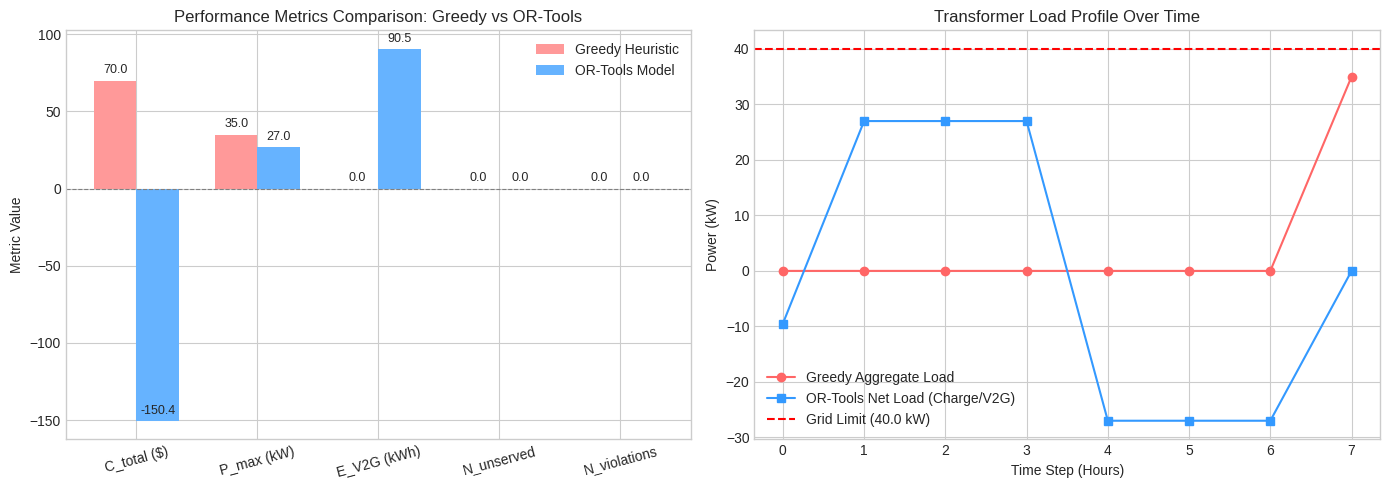

Visualizations generated successfully and saved to 'output/classical_performance_comparison.png'!


In [14]:
# Cell 6: Visualizations for Hackathon Presentation
import matplotlib.pyplot as plt
import numpy as np
import json

# Set plot style
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: Side-by-Side Metrics Comparison Bar Chart ---
with open("output/greedy_metrics.json", "r") as f:
    g_metrics = json.load(f)
with open("output/ortools_metrics.json", "r") as f:
    o_metrics = json.load(f)

metrics_keys = ['C_total', 'P_max', 'E_V2G', 'N_unserved', 'N_violations']
greedy_values = [g_metrics[k] for k in metrics_keys]
ortools_values = [o_metrics[k] for k in metrics_keys]

x = np.arange(len(metrics_keys))
width = 0.35

rects1 = axes[0].bar(x - width/2, greedy_values, width, label='Greedy Heuristic', color='#ff9999')
rects2 = axes[0].bar(x + width/2, ortools_values, width, label='OR-Tools Model', color='#66b3ff')

axes[0].set_ylabel('Metric Value')
axes[0].set_title('Performance Metrics Comparison: Greedy vs OR-Tools')
axes[0].set_xticks(x)
axes[0].set_xticklabels(['C_total ($)', 'P_max (kW)', 'E_V2G (kWh)', 'N_unserved', 'N_violations'], rotation=15)
axes[0].legend()
axes[0].axhline(0, color='grey', linewidth=0.8, linestyle='--')

# Add values on top of bars
def autolabel(rects, ax):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.1f}' if isinstance(height, float) else str(height),
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

autolabel(rects1, axes[0])
autolabel(rects2, axes[0])

# --- Plot 2: Aggregate Grid Power Profiles ---
prices = sample_problem_data["prices"]
grid_limit = sample_problem_data["grid_limit"]
time_steps = len(prices)

# Re-simulate greedy grid profile for plotting
greedy_profile = [0.0] * time_steps
for ev_id, prof in solve_greedy_heuristic(sample_problem_data)[0]['ev_power_profiles'].items():
    for t, p in enumerate(prof):
        greedy_profile[t] += p

# Re-simulate OR-Tools grid profile for plotting
ortools_profile = [0.0] * time_steps
for ev_id, prof in solve_ortools_model(sample_problem_data, warm_start_hint=solve_greedy_heuristic(sample_problem_data)[0])[0]['ev_power_profiles'].items():
    for t, p in enumerate(prof):
        ortools_profile[t] += p

axes[1].plot(range(time_steps), greedy_profile, marker='o', linestyle='-', label='Greedy Aggregate Load', color='#ff6666')
axes[1].plot(range(time_steps), ortools_profile, marker='s', linestyle='-', label='OR-Tools Net Load (Charge/V2G)', color='#3399ff')
axes[1].axhline(grid_limit, color='red', linestyle='--', linewidth=1.5, label=f'Grid Limit ({grid_limit} kW)')

axes[1].set_xlabel('Time Step (Hours)')
axes[1].set_ylabel('Power (kW)')
axes[1].set_title('Transformer Load Profile Over Time')
axes[1].set_xticks(range(time_steps))
axes[1].legend()

plt.tight_layout()
plt.savefig("output/classical_performance_comparison.png", dpi=300)
plt.show()
print("Visualizations generated successfully and saved to 'output/classical_performance_comparison.png'!")